# Analysis of parking occupancy
Compared to archive: Take base occupancy as parking supply and analyse the relative overshoot during the policy case.

In [2]:
import pandas as pd
%config InlineBackend.figure_format = 'retina'

base_path = "/Users/paulh/runs-svn/matsim-berlin/autofrei/1pct-v6.4/berlin-autofrei-v6.4-baseCaseCtdExtended/"
base_parking = pd.read_csv(base_path + "parking_occupancy_autofrei-1pct.csv.zst")

policy_parking = pd.read_csv(
    "/Users/paulh/runs-svn/matsim-berlin/autofrei/1pct-v6.4/berlin-autofrei-v6.4-policy/parking_occupancy_autofrei-1pct.csv.zst")

pct = 0.01

In [3]:
# join base and policy on linkId.
merged = base_parking.merge(policy_parking, on="linkId", suffixes=("_base", "_policy"))
merged["occupancy_diff"] = merged["occupancy_policy"] - merged["occupancy_base"]
merged["relative_overshoot"] = merged["occupancy_diff"] / merged["occupancy_base"].replace(0,
                                                                                           pd.NA)  # avoid division by zero, set to NA
merged

,linkId,from_time_base,to_time_base,length_base,occupancy_base,initial_base,from_time_policy,to_time_policy,length_policy,occupancy_policy,initial_policy,occupancy_diff,relative_overshoot
0,-218722226,23908.0,26274.0,851.81,1.0,0.0,25325.0,27691.0,851.81,1.0,0.0,0.0,0.0
1,-458915637#0,46210.0,47899.0,213.59,3.0,1.0,45523.0,46944.0,213.59,2.0,0.0,-1.0,-0.333333
2,-25436865#3,34062.0,40611.0,221.24,1.0,0.0,34058.0,40611.0,221.24,1.0,0.0,0.0,0.0
3,15805101#0,72746.0,73446.0,91.18,1.0,0.0,75412.0,76112.0,91.18,1.0,0.0,0.0,0.0
4,1117976084,53124.0,53459.0,144.20,1.0,0.0,52921.0,53256.0,144.20,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
22717,-153608616#1,44519.0,46754.0,158.07,1.0,0.0,44516.0,46751.0,158.07,1.0,0.0,0.0,0.0
22718,22962092,64636.0,67811.0,114.89,1.0,0.0,60083.0,63258.0,114.89,1.0,0.0,0.0,0.0
22719,-24214516,47453.0,48561.0,287.63,5.0,3.0,52727.0,52894.0,287.63,6.0,3.0,1.0,0.2
22720,-25814594#0,26032.0,50884.0,190.92,1.0,0.0,26469.0,50884.0,190.92,1.0,0.0,0.0,0.0


In [4]:
import geopandas as gpd

df_links = pd.read_csv(
    base_path + "berlin-v6.4.output_links.csv.zst",
    sep=";",
    compression="zstd",
    dtype={"link": "string"},
    low_memory=False,
)

links = gpd.GeoDataFrame(
    df_links[~df_links["link"].str.contains("pt_")],
    geometry=gpd.GeoSeries.from_wkt(df_links["geometry"], crs="EPSG:25832"),
)
links

,link,from_node,to_node,length,freespeed,capacity,lanes,modes,vol_car,vol_commercial_goods_car,...,vol_truck,allowed_speed,maxInflowUsedInQsim,name,speed_factor,restricted_lanes,hbefa_road_type,storageCapacityUsedInQsim,type,geometry
0,-1000055665,6773970060,267855868,28.01,4.634,634.0,1.0,"bike,car,commercial_goods_car,freight,ride,truck",0,0,...,0,13.89,1053.102038,Lindenweg,4.634,NaN,URB/Access/50,NaN,highway.residential,"LINESTRING (796573.1 5797464.9, 796580.93 5797..."
1,-1000098209,29266788,29266795,58.56,2.554,800.0,1.0,"bike,car,commercial_goods_car,freight,ride,truck",0,0,...,0,2.78,760.043646,Lilli-Henoch-Straße,2.554,NaN,URB/Access/30,0.082185,highway.living_street,"LINESTRING (800578.77 5830375.13, 800629.32 58..."
2,-100012092,2288369966,1017979482,223.51,9.344,1896.0,1.0,"bike,car,commercial_goods_car,freight,ride,truck",0,0,...,0,13.89,1383.203395,Dorfstraße,9.344,NaN,URB/Local/50,0.408496,highway.tertiary,"LINESTRING (807040 5714450.85, 806856.97 57145..."
3,-1000121005,9231911647,3869622346,136.97,10.460,1933.0,1.0,"bike,car,commercial_goods_car,freight,ride,truck",15,3,...,0,13.89,1430.264357,Lichtenrader Straße,10.460,NaN,URB/Access/50,0.246820,highway.unclassified,"LINESTRING (799342.3 5811143.42, 799386.89 581..."
4,-1000268036,94673071,7829689846,69.88,7.133,800.0,1.0,"bike,car,commercial_goods_car,freight,ride,truck",1,5,...,0,8.33,1262.515118,Roseggerstraße,7.133,NaN,URB/Access/30,NaN,highway.residential,"LINESTRING (802003.09 5823888.17, 801962.85 58..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
213956,999753858,cluster_10219572135_247947537_4796865042_80644...,8310059767,21.17,3.231,1666.0,1.0,bike,0,0,...,0,5.56,873.518677,NaN,3.231,NaN,URB/Access/30,0.053835,highway.cycleway,"LINESTRING (809649.3 5829245.86, 809633.22 582..."
213957,999943085,9135760767,cluster_9193459685_95920977,165.26,5.561,1412.0,1.0,bike,0,0,...,0,5.56,1143.336874,NaN,5.561,NaN,URB/Access/30,0.272124,highway.path,"LINESTRING (813176.2 5831254, 813018.57 583120..."
213958,999943090#1,cluster_9193459685_95920977,cluster_9196165417_95920978,147.05,5.625,1412.0,1.0,bike,0,0,...,0,5.56,1148.936170,NaN,5.625,NaN,URB/Access/30,0.240959,highway.path,"LINESTRING (813018.57 5831208.39, 812877.65 58..."
213959,999948146#1,258956777,268072032,175.76,7.158,800.0,1.0,"bike,car,commercial_goods_car,freight,ride,truck",3,0,...,0,8.33,1264.143168,Goethestraße,7.158,NaN,URB/Access/30,NaN,highway.residential,"LINESTRING (801940.36 5803217.47, 802026.89 58..."


In [5]:
# join merged with links on linkId and link, keep all columns
final = links.merge(merged, left_on="link", right_on="linkId", how="left")
final_3857 = final.to_crs(epsg=3857)
final_3857["geometry"] = final_3857.geometry.simplify(2)
# final_3857["relative_overshoot"] = final_3857["relative_overshoot"]
# final_3857[final_3857["link"] == "306046325"]
final_3857

,link,from_node,to_node,length,freespeed,capacity,lanes,modes,vol_car,vol_commercial_goods_car,...,length_base,occupancy_base,initial_base,from_time_policy,to_time_policy,length_policy,occupancy_policy,initial_policy,occupancy_diff,relative_overshoot
0,-1000055665,6773970060,267855868,28.01,4.634,634.0,1.0,"bike,car,commercial_goods_car,freight,ride,truck",0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,-1000098209,29266788,29266795,58.56,2.554,800.0,1.0,"bike,car,commercial_goods_car,freight,ride,truck",0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,-100012092,2288369966,1017979482,223.51,9.344,1896.0,1.0,"bike,car,commercial_goods_car,freight,ride,truck",0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,-1000121005,9231911647,3869622346,136.97,10.460,1933.0,1.0,"bike,car,commercial_goods_car,freight,ride,truck",15,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,-1000268036,94673071,7829689846,69.88,7.133,800.0,1.0,"bike,car,commercial_goods_car,freight,ride,truck",1,5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
213956,999753858,cluster_10219572135_247947537_4796865042_80644...,8310059767,21.17,3.231,1666.0,1.0,bike,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
213957,999943085,9135760767,cluster_9193459685_95920977,165.26,5.561,1412.0,1.0,bike,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
213958,999943090#1,cluster_9193459685_95920977,cluster_9196165417_95920978,147.05,5.625,1412.0,1.0,bike,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
213959,999948146#1,258956777,268072032,175.76,7.158,800.0,1.0,"bike,car,commercial_goods_car,freight,ride,truck",3,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Number of links with relative overshoot > 4: 3
Percentiles of relative_overshoot:
0.250    0.0
0.500    0.0
0.750    0.0
0.900    0.0
0.950    0.0
0.990    1.0
0.999    2.0
Name: relative_overshoot, dtype: object


<Axes: ylabel='Frequency'>

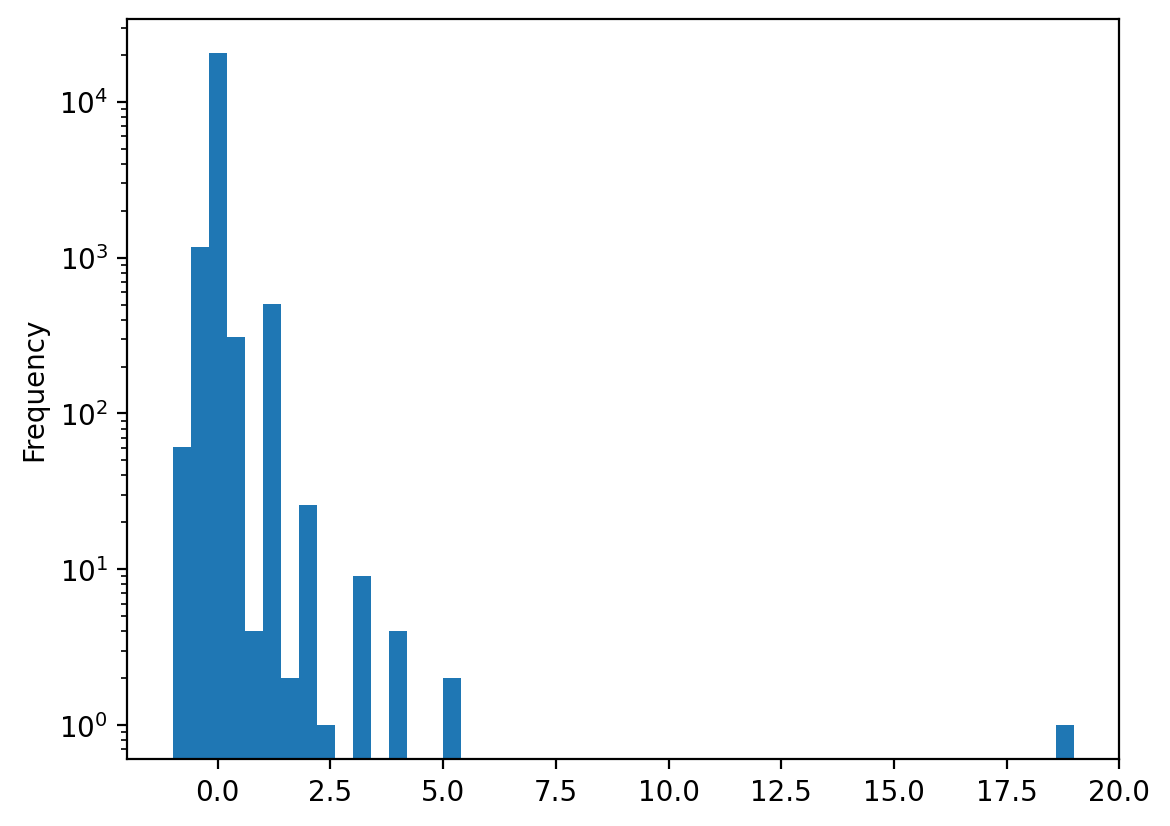

In [6]:
# count how many links have a relative_overshoot of >4
num_links_overshoot = (final_3857["relative_overshoot"] > 4).sum()
print(f"Number of links with relative overshoot > 4: {num_links_overshoot}")

# print percentiles of relative_overshoot
percentiles = final_3857["relative_overshoot"].quantile([0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 0.999])
print("Percentiles of relative_overshoot:")
print(percentiles)

# make a hist plot of relative_overshoot, excluding NA values and log y axis
final_3857["relative_overshoot"].dropna().plot.hist(bins=50, log=True)

In [49]:
value_col = "relative_overshoot"

final_3857[value_col] = pd.to_numeric(final_3857[value_col], errors="coerce")
gdf_plot = final_3857.loc[
    final_3857[value_col].notna() & (final_3857[value_col] != 0) & (final_3857[value_col] > 1.5)].copy()

# print row count of gdf_plot
zone = gpd.read_file('../../../../input/v6.4/umweltzone/Umweltzone_Berlin.shp')

# gdf_plot[gdf_plot.geometry.within(zone.to_crs(epsg=3857).union_all())].shape[1]
filtered = gdf_plot[gdf_plot.geometry.within(zone.to_crs(epsg=3857).union_all())]
filtered

,link,from_node,to_node,length,freespeed,capacity,lanes,modes,vol_car,vol_commercial_goods_car,...,length_base,occupancy_base,initial_base,from_time_policy,to_time_policy,length_policy,occupancy_policy,initial_policy,occupancy_diff,relative_overshoot
7056,-110450332,27786143,2031644367,251.82,7.334,3266.0,2.0,"bike,car,commercial_goods_car,freight,ride,truck",16,37,...,251.82,1.0,1.0,72442.0,75831.0,251.82,3.0,2.0,2.0,2.0
7314,-110785555#2,1818648896,25663395,112.15,6.420,2019.0,2.0,"bike,car,commercial_goods_car,freight,ride,truck",3,51,...,112.15,1.0,0.0,46312.0,51669.0,112.15,3.0,0.0,2.0,2.0
56836,-37995740#1,4308915630,cluster_4308915627_446257324,63.41,4.962,2535.0,3.0,"bike,car,commercial_goods_car,freight,ride,truck",25,81,...,63.41,1.0,0.0,38322.0,39399.0,63.41,3.0,0.0,2.0,2.0
79146,-67553868#2,cluster_10235847333_10235847336_21487269_27785840,cluster_26865688_3589711224_3589711225_7728293...,164.56,5.833,2055.0,2.0,"bike,car,commercial_goods_car,freight,ride,truck",23,36,...,164.56,1.0,0.0,50163.0,51004.0,164.56,3.0,0.0,2.0,2.0
99601,1083602355,12614651,29785844,75.86,8.149,4131.0,2.0,"bike,car,commercial_goods_car,freight,ride,truck",20,97,...,75.86,1.0,1.0,5964.0,33116.0,75.86,3.0,2.0,2.0,2.0
103747,1116571742#0,cluster_3021603099_9146865093,cluster_26736167_9146865094,166.10,9.128,6761.0,4.0,"bike,car,commercial_goods_car,freight,ride,truck",75,104,...,166.10,1.0,0.0,65927.0,84658.0,166.10,4.0,3.0,3.0,3.0
103865,1117262057,10218729546,4213073590,234.56,7.619,3910.0,2.0,"bike,car,commercial_goods_car,freight,ride,truck",5,50,...,234.56,1.0,0.0,41915.0,44208.0,234.56,3.0,0.0,2.0,2.0
105755,117915138#0,cluster_27186874_27186876_27186878_27186880,cluster_27785302_27785303_27785304_27785305_#2...,438.77,6.643,2117.0,3.0,"bike,car,commercial_goods_car,freight,ride,truck",23,26,...,438.77,1.0,0.0,99224.0,100167.0,438.77,3.0,2.0,2.0,2.0
109922,142161212#0,cluster_27186882_27186884,cluster_207541991_2883691331_31355884,197.84,6.140,4717.0,3.0,"bike,car,commercial_goods_car,freight,ride,truck",28,23,...,197.84,1.0,0.0,30302.0,31296.0,197.84,4.0,2.0,3.0,3.0
116935,160130967#2,cluster_10238037542_29123036,cluster_10238037544_29123037,169.39,8.286,5071.0,3.0,"bike,car,commercial_goods_car,freight,ride,truck",36,20,...,169.39,1.0,0.0,45933.0,46294.0,169.39,3.0,0.0,2.0,2.0


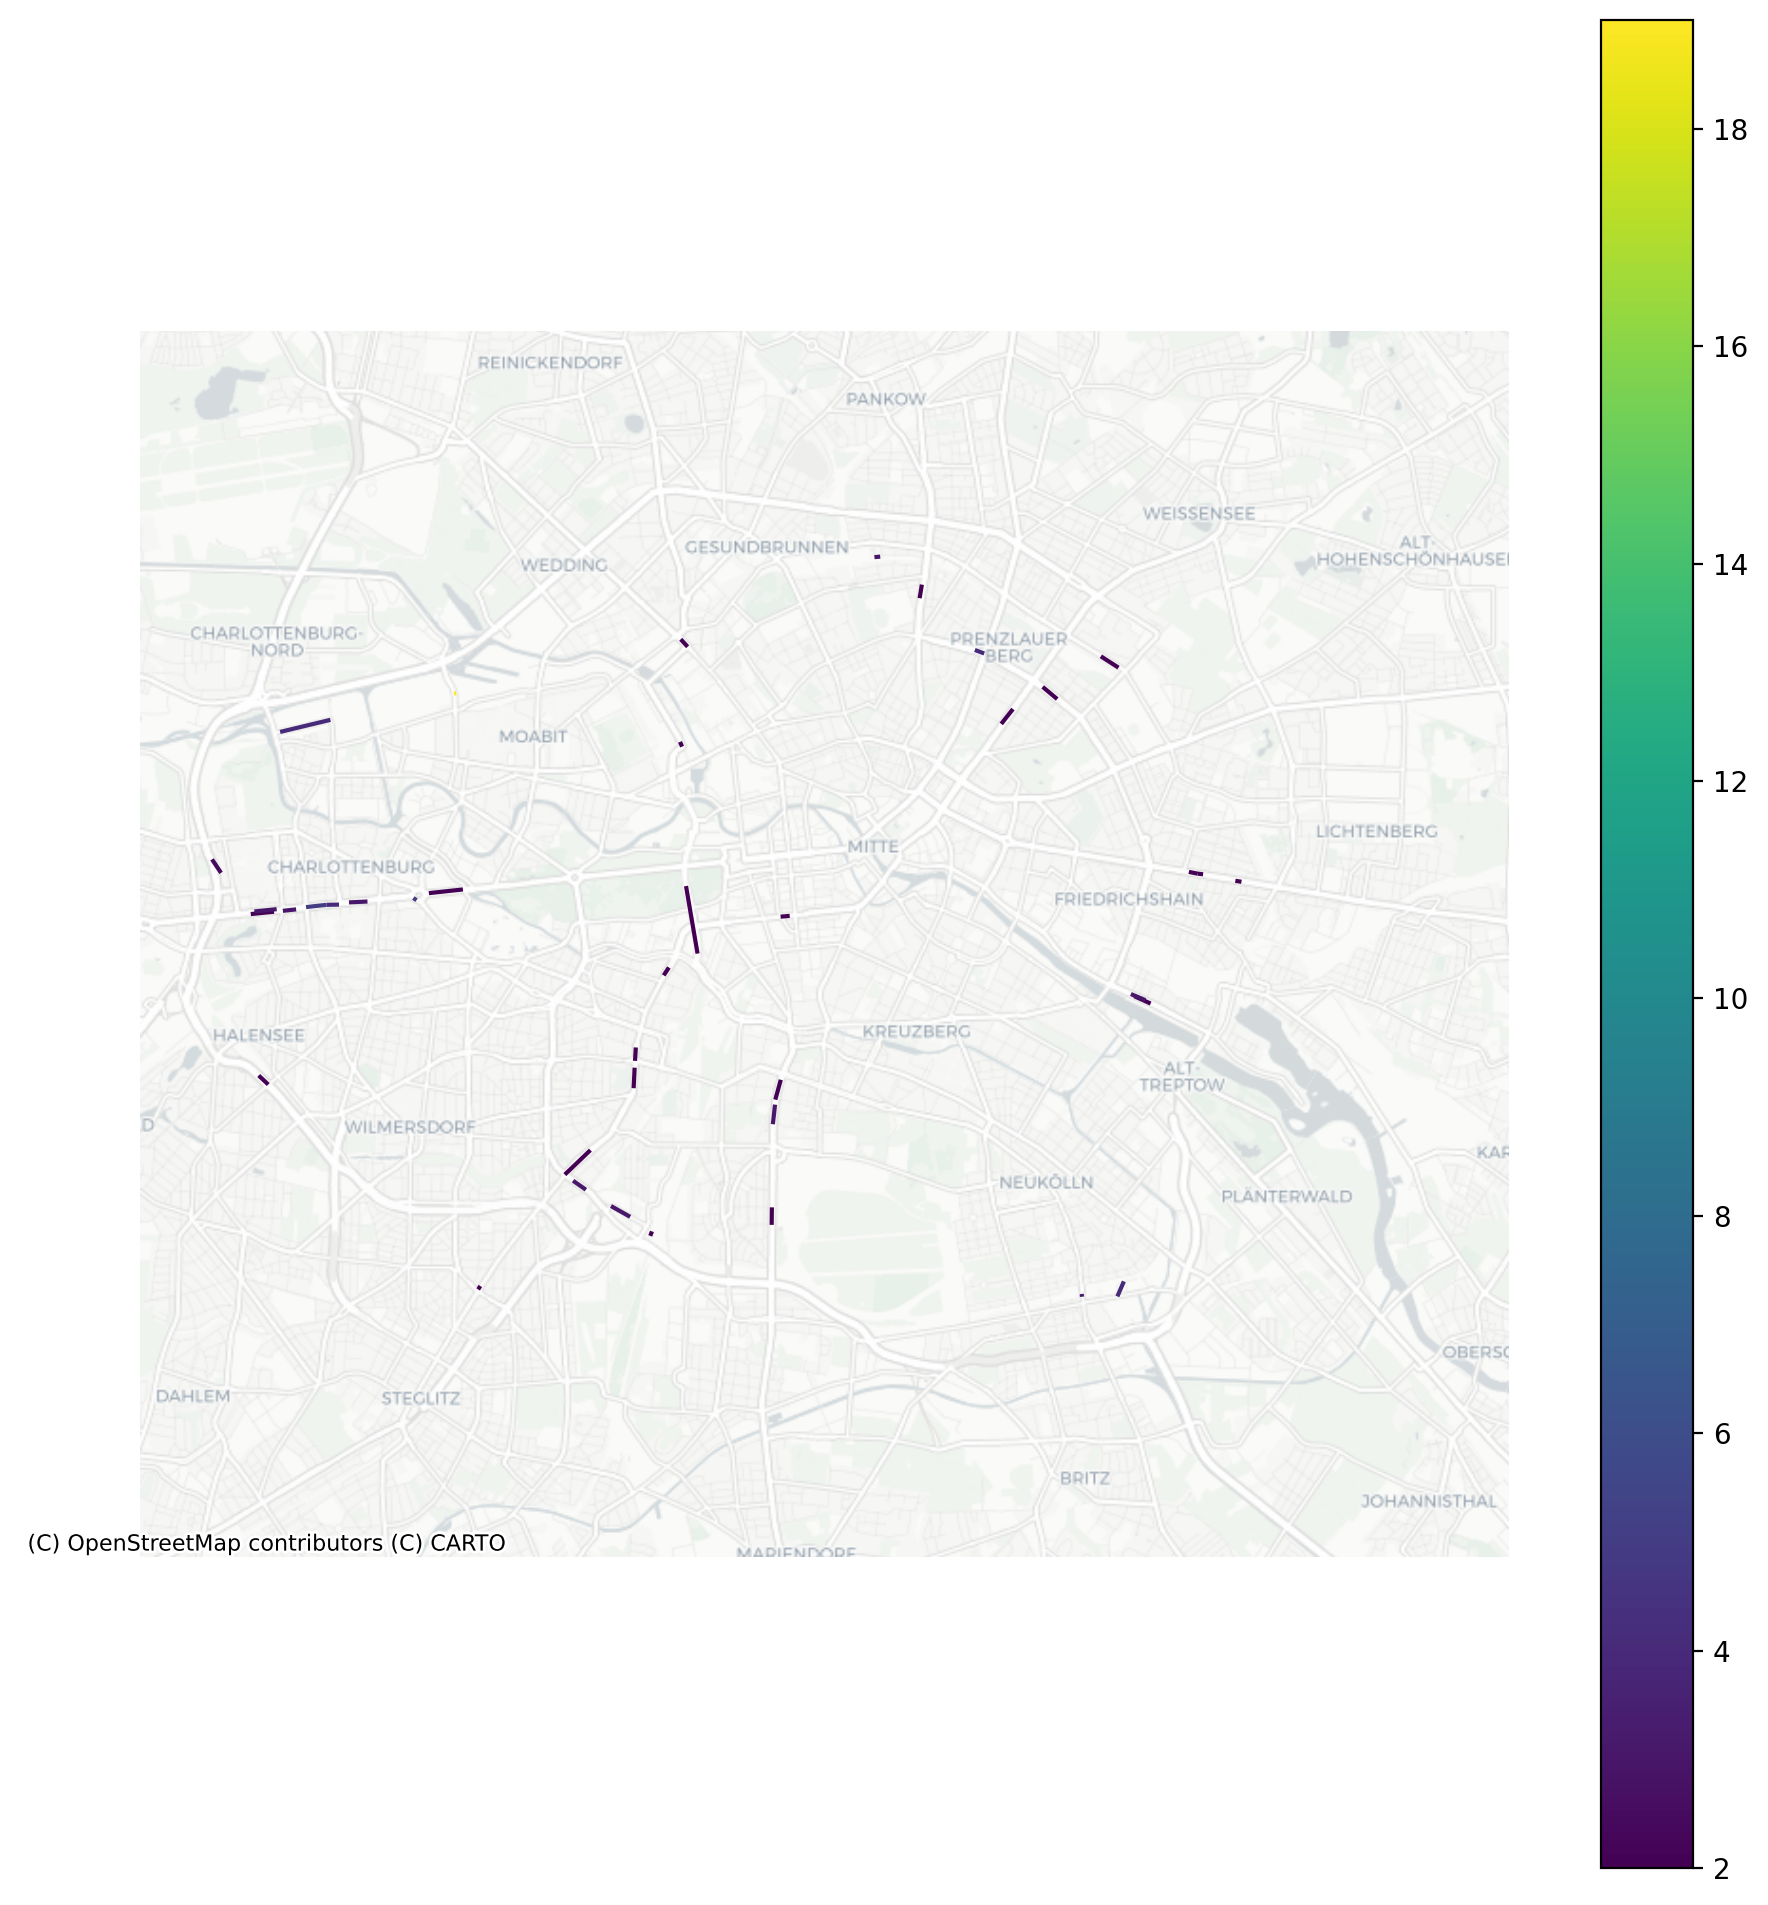

In [38]:

import contextily as ctx
import matplotlib.pyplot as plt

bezirke = gpd.read_file("/Users/paulh/git/matsim-berlin/input/v6.4/bezirksgrenzen.geojson")
bezirke = bezirke.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(12, 12))

# vmin = gdf_plot[value_col].min()
# vmax = gdf_plot[value_col].max()
#
# cmap = plt.cm.viridis
# norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

gdf_plot.plot(
    column=value_col,
    ax=ax,
    # cmap=cmap,
    # norm=norm,
    legend=True,  # <- important: turn off geopandas legend
    # edgecolor="none",
)
#
# sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
# sm.set_array([])  # needed for older mpl behavior
# cbar = fig.colorbar(sm, ax=ax)
# cbar.set_label("Relative Overshoot")

ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=12)
ax.set_axis_off()

minx, miny, maxx, maxy = bezirke.total_bounds

x_diff = maxx - minx
y_diff = maxy - miny
buffer_factor = -0.3
minx -= x_diff * buffer_factor * 0.8
maxx += x_diff * buffer_factor * 1.2
miny -= y_diff * buffer_factor
maxy += y_diff * buffer_factor

ax.set_xlim([minx, maxx])
ax.set_ylim([miny, maxy])

plt.show()


In [25]:
gdf_plot.sort_values("relative_overshoot", ascending=False)
print(final_3857[value_col].dtype)

object
